# Galaxy Scaling Relations

This tutorial notebook will walk you through how to plot simple scaling relations for galaxies using column queries in opencosmo. Lets start by importing the packages we will need:

In [ ]:
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt

## Loading in Data

We will use opencosmo to read in a the properties of 100,000 galaxies with a stellar mass between $M_* = [10^{11},10^{12}] M_\odot$. Once we open the file with opencosmo, many useful galaxy properties are at our fingertips with just some simple column calls. As a sanity check, let's open the data and plot the distribution of galaxy masses for our sample.

We can open the data by feeding the file path to `.open()`. Then, we can get the data from a column by using `.select()` with the specific column name. Note that OpenCosmo will only give you the data once you use `.get_data()`. This allows you to interact with the data without loading in the whole dataset. This means that you should only use `.get_data()` **AFTER** you have already filtered the data or selected the columns you want. This avoids loading large amounts of data to your machine.

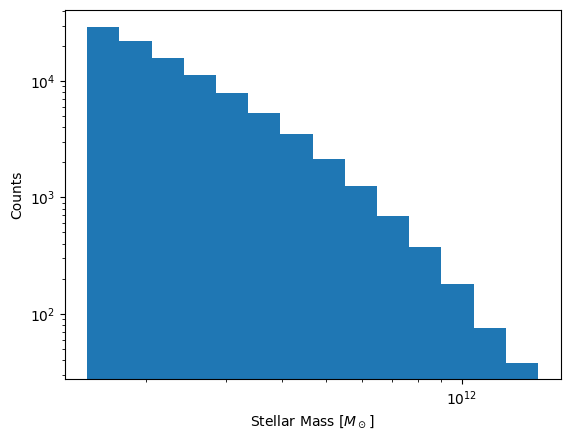

In [ ]:
#read in the data
data = oc.open('filtered_galaxy_catalog.hdf5').take(100000)

#select column, and get data
#opencosmo automatically gives data with astropy units.
#We use .value to drop the astropy units for the log line below
mass = data.select('gal_mass_star').get_data().value

#plot with log bins
bins = np.logspace(np.log10(mass.min()), np.log10(mass.max()), 15)
plt.hist(mass, bins = bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass [$M_\odot$]', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.show()

## Scaling Relations

> **Note:**
> 
>Our galaxy mass range and sample is extremely limited, for the sake of making the following simple plots quick and easy to produce. Due to this limited range, the relations we plot may look slightly off. The reader is encouraged to use more data or better filters to reproduce these plots better on their own!


Everything looks normal! Let's start by plotting the Tully-Fisher Relation. We will assume a constant mass-to-light ratio ($M/L$) so we can use stellar mass as a proxy for luminosity. To make these plots the only thing we need to do is select the columns we want data from and plot.

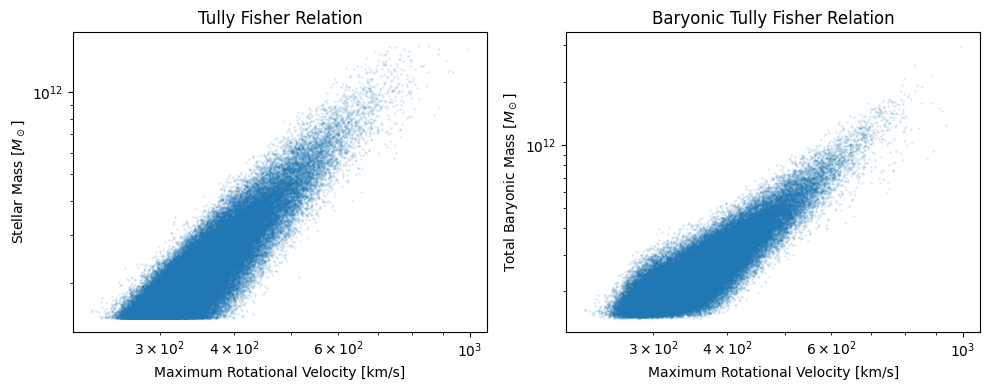

In [ ]:
#remember, .get_data() after you select!
Vrot = data.select('gal_max_cir_vel').get_data().value # maximum rotational velocity
Mbar = data.select('gal_mass_bar').get_data().value # baryonic mass

#plot!
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].scatter(Vrot, mass, s=1, alpha = 0.1)
ax[0].set_xlabel('Maximum Rotational Velocity [km/s]')
ax[0].set_ylabel('Stellar Mass [$M_\odot$]')
ax[0].set_title('Tully Fisher Relation')
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].scatter(Vrot, Mbar, s=1, alpha = 0.1)
ax[1].set_xlabel('Maximum Rotational Velocity [km/s]')
ax[1].set_ylabel('Total Baryonic Mass [$M_\odot$]')
ax[1].set_title('Baryonic Tully Fisher Relation')
ax[1].set_xscale('log')
ax[1].set_yscale('log')

plt.tight_layout()
plt.show()

Note that the relation isn't perfect since we never explicitly masked out any elliptical galaxies. Let's also plot the Faber-Jackson Relation, since most objects of this mass are ellipticals anyway.

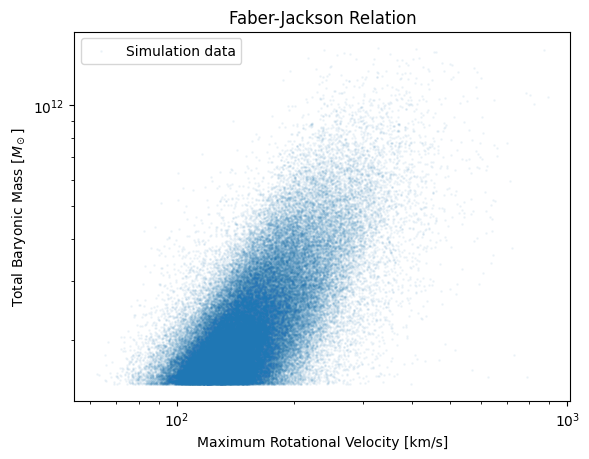

In [ ]:
#get column data
v = data.select('gal_LOS_stellar_vel_disp').get_data().value

#plot
plt.scatter(v, mass, s=1, alpha = 0.05)
plt.xlabel('Maximum Rotational Velocity [km/s]', fontsize=14)
plt.ylabel('Total Baryonic Mass [$M_\odot$]', fontsize=14)
plt.title('Faber-Jackson Relation')
plt.xscale('log')
plt.yscale('log')
plt.legend()

The simulation also tracks star formation rate, which we can use to calculate the fraction of our galaxies that are quenched or starforming. To do so, we will plot our galaxies in the SFR-$M_*$ parameter space.

[9.99999978e-03 1.07294545e-01 1.07861258e-01 ... 5.97372437e+01
 6.52453232e+01 7.44666595e+01]


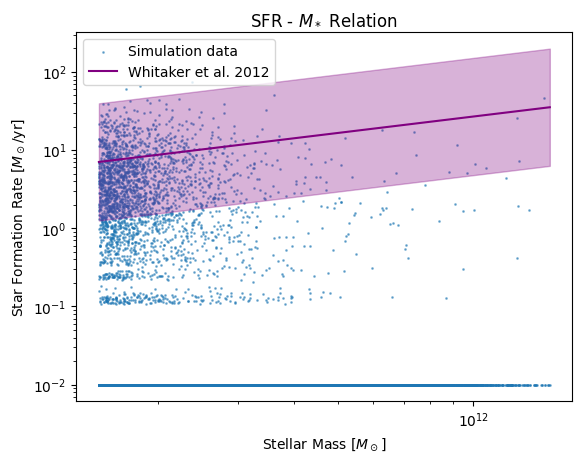

In [ ]:
#galaxy SFR
sfr = data.select('gal_sfr').get_data().value

#whitaker et al 2012 line
M_w = np.logspace( np.log10(mass.min()), np.log10(mass.max()))
whit = 0.7*(np.log10(M_w) - 10.5) + 0.38

#set immeasureable SFR to some arbitrary low value
sfr[sfr == 0.] = 1e-2

#plot
plt.scatter(mass, sfr, s=1, alpha = 0.5, label='Simulation data')
plt.plot(M_w, 10**whit, color = 'purple', label = 'SFMS Whitaker+ 2012')
plt.fill_between(M_w, 10**(whit-0.75), 10**(whit+0.75), color = 'purple', alpha = 0.3)
plt.xlabel('Stellar Mass [$M_\odot$]', fontsize=14)
plt.ylabel('Star Formation Rate [$M_\odot$/yr]', fontsize=14)
plt.title('SFR - $M_*$ Relation')
plt.xscale('log')
plt.yscale('log')
plt.legend()

> **Question:**
> 
> Do you notice how there seem to be bands and gaps in the data at low SFR? What do you think causes this?
> To see the answer, check the comment in this markdown cell.

<!-- Answer: The bands are a result of the simulation resolution. The band around 0.1 SFR are galaxies that only formed 1 star particle. The next band are galaxies that only formed 2 star particles, and so on. We can't get an SFR between these values easily because all the star particles have similar masses and we can't form 1.5 star particles for example.-->

We have plotted the Star Formation Main Sequence (SFMS, Whitaker et al. 2012) alongside the simulation data and we have placed all immeasureable SFRs to $10^{-2}$. Now we can make one more simple plot: the quenched fraction as a function of mass. The quenched fraction is the fraction of galaxies that lie below 0.75 dex of the SFMS, represented by the purple shaded region in the above plot.

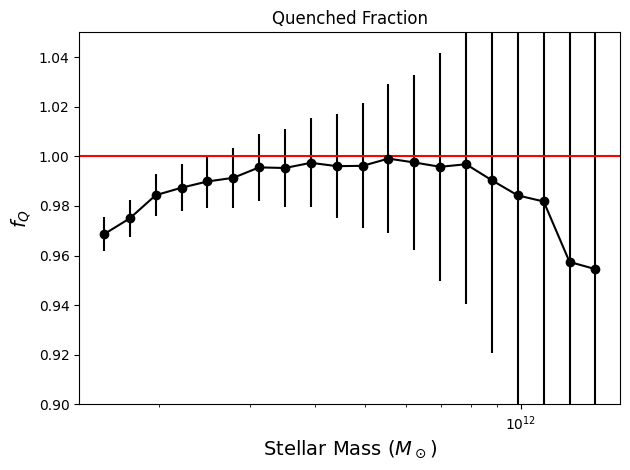

In [ ]:
#Overall quenched Fraction
whit = 0.7*(np.log10(mass) - 10.5) + 0.38 #whitaker line at masses
fq = np.sum([sfr < 10**(whit-0.75)])/len(sfr) 

#quenched Fraction in mass bins
Mbins = np.logspace(np.log10(mass.min()), np.log10(mass.max()), 21)
fq_m = np.zeros(len(Mbins)-1)
fq_err = np.zeros(len(Mbins)-1)
for m in range(len(Mbins) -1):
    fq_m[m] = np.sum([(sfr < 10**(whit-0.75)) & (mass > Mbins[m]) & (mass < Mbins[m+1])])/np.sum([(mass > Mbins[m]) & (mass < Mbins[m+1])])
    fq_err[m] = 1/np.sqrt(np.sum([(mass > Mbins[m]) & (mass < Mbins[m+1])])) # Assume a simple poisson error

#plot
cen =  np.sqrt(Mbins[:-1] * Mbins[1:]) #bin centers
plt.errorbar(cen, fq_m, yerr = fq_err, fmt='o', color = 'k')
plt.plot(cen, fq_m, color = 'k')
plt.axhline(y = 1, color = 'r')
plt.title(f'Quenched Fraction')
plt.xscale("log")
plt.ylabel('$f_Q$', fontsize=14)
plt.xlabel('Stellar Mass ($M_\odot$)',fontsize = 14)
plt.ylim(0.9,1.05)
plt.tight_layout()
plt.show()
plt.close()

As expected for galaxies around this mass, the quenched fraction is close to 1!

These are just a few examples of some plots you can make right out of the box with opencosmo. Many more plots can be made with the values directly calculated in the simulation. Try to make some plots of your own!